<a href="https://colab.research.google.com/github/Harsh-Raghuvanshi/ActiveDomainAdaptation/blob/main/ResearchModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installing Libraries (if not already installed)
!pip install torchvision numpy scikit-learn matplotlib

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 844.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [3]:
# Loading MNIST and USPS Datasets
# Defining transformations for MNIST and USPS

transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Ensure same size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load MNIST (source domain)
mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Load USPS (target domain)
usps = datasets.USPS(root='./data', train=True, transform=transform, download=True)
usps_test = datasets.USPS(root='./data', train=False, transform=transform, download=True)

# DataLoaders
mnist_loader = DataLoader(mnist, batch_size=64, shuffle=True)
usps_loader = DataLoader(usps, batch_size=64, shuffle=True)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 47.8MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.50MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 6.58M/6.58M [00:02<00:00, 3.06MB/s]


100%|██████████| 1.83M/1.83M [00:01<00:00, 1.17MB/s]


In [ ]:
transform_svhn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert RGB to grayscale
    transforms.Resize((28, 28)),  # Ensure same size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Reload SVHN with the updated transform
svhn = datasets.SVHN(root='./data', split='train', transform=transform_svhn, download=True)
svhn_test = datasets.SVHN(root='./data', split='test', transform=transform_svhn, download=True)

# DataLoaders
svhn_loader = DataLoader(svhn, batch_size=64, shuffle=True)
svhn_test_loader = DataLoader(svhn_test, batch_size=64)


# Get 6000 random indices
random_indices = np.random.choice(len(svhn_test), 6000, replace=False)

# Create a subset dataset with only 6000 random samples
svhn_test_subset = Subset(svhn_test, random_indices)

# Create a DataLoader for the subset
svhn_test_subset_loader = DataLoader(svhn_test_subset, batch_size=64, shuffle=True)

Using downloaded and verified file: ./data/train_32x32.mat
Using downloaded and verified file: ./data/test_32x32.mat


In [4]:
# Cross Checking availability of data and deciding budget as 10% of target train set size
print("The size of mnist train and test is ", len(mnist), len(mnist_test))
print("The size of usps train and test is ", len(usps), len(usps_test))
# print("The size of svhn train and test is ", len(svhn), len(svhn_test))
# print("The size of svhn subset for test is ",len(svhn_test_subset))
budget = int(700)
print("The budget is : ",budget)

The size of mnist train and test is  60000 10000
The size of usps train and test is  7291 2007
The budget is :  700


In [5]:
# Defining the Simple Convultional neural network Model

import torch.nn as nn
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)


In [6]:
# Training on MNIST (Source Domain)
x_points = []
y_points = []
def train_source_domain(model, loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        x_points.append(epoch+1)
        y_points.append(running_loss/len(loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader)}")

train_source_domain(model, mnist_loader)

# Saving the base model after training for ressting it for various approaches
torch.save(model.state_dict(), '/content/models/base_cnn_model')






Epoch 1/5, Loss: 0.15583844299910704
Epoch 2/5, Loss: 0.047071152818458736
Epoch 3/5, Loss: 0.03229717727003893
Epoch 4/5, Loss: 0.02394649864752841
Epoch 5/5, Loss: 0.018308769008230683


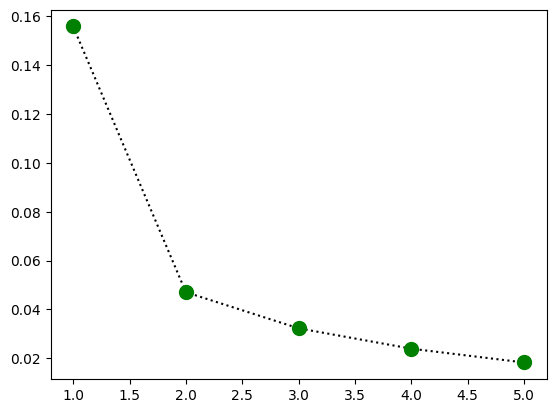

In [7]:
plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
plt.show()

In [8]:
def resetting_base_model(model_path='/content/models/base_cnn_model'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    try:
        model.load_state_dict(torch.load(model_path))
        print(f"Model successfully loaded from {model_path}.")
    except FileNotFoundError:
        print(f"Error: Model checkpoint not found at {model_path}")
        return None
    except Exception as e:
        print(f"Error while resetting model: {e}")
        return None

    model.train()  # Set to training mode for fine-tuning
    return model


In [9]:
# Method Module [ will contain all necessary function for various active domain adaptation techniques]


# Compute Average Uncertainty
def compute_average_uncertainty(model, target_loader):
    model.eval()
    uncertainties = []

    with torch.no_grad():
        for images, _ in target_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-5), dim=1)
            uncertainties.extend(entropy.cpu().numpy())

    return np.mean(uncertainties)


# Fine-tuning function
def fine_tune_model(model, loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    net_avg_loss=0.0
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Fine-tuning Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(loader)}")
        net_avg_loss+=(running_loss/len(loader))
    return net_avg_loss / epochs


# Uncertainty Sampling
def uncertainty_sampling(model, target_loader, n_samples=100):
    model.eval()
    uncertainties = []
    all_indices = []

    with torch.no_grad():
        for i, (images, _) in enumerate(target_loader):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-5), dim=1)
            uncertainties.extend(entropy.cpu().numpy())
            all_indices.extend(range(i * target_loader.batch_size, (i + 1) * target_loader.batch_size))

    # Get indices of top uncertain samples
    uncertain_indices = np.argsort(uncertainties)[-n_samples:]
    return uncertain_indices


# Diversity Sampling
def diversity_sampling(target_data, n_samples=100):
    data = np.array([img.numpy().flatten() for img, _ in target_data])
    kmeans = KMeans(n_clusters=n_samples).fit(data)
    cluster_centers = kmeans.cluster_centers_
    indices, _ = pairwise_distances_argmin_min(cluster_centers, data)
    return indices


# Evaluating model
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [10]:

# Active Domain Adaptation using Uncertainity sampling with Fixed Budget

def active_domain_adaptation_with_uncertainity_sampling(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]


        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)


    print("Active Domain Adaptation with Uncertainity Sampling completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.show()



In [11]:
#Active Domain adaptation using Diversity sampling with fixed Budget

def active_domain_adaptation_with_diversity_sampling(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break
        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Diversity")
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]
        combined_indices = (
            diverse_indices[: int(current_batch)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Diversity Sampling completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.show()



In [12]:
# Adaptive Active Domain Adaptation using Hybrid approach with Fixed Budget

def active_domain_adaptation_with_fixed_weighting(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        # Adjust weights based on uncertainty reduction
        if n_iterations//2 < iteration:
          weight_uncertainty = 1
          weight_diversity = 0
        else:
          weight_uncertainty = 0
          weight_diversity = 1

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty}, Diversity: {weight_diversity}")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Perform Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Dynamic Weighting completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.show()



In [13]:
# Adaptive Active Domain Adaptation with Dynamic Budget Allocation

def active_domain_adaptation_with_dynamic_weighting(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    weight_uncertainty = 0.9  # Start with high weight on uncertainty sampling
    weight_diversity = 0.1

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty}, Diversity: {weight_diversity}")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Perform Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)


        # Adjust weights based on uncertainty reduction
        avg_uncertainty = compute_average_uncertainty(model, target_loader)
        if avg_uncertainty < 0.5:  # Example threshold for reducing uncertainty weight
            weight_uncertainty = max(0.1, weight_uncertainty - 0.15)
            weight_diversity = min(0.9, weight_diversity + 0.15)

    print("Active Domain Adaptation with Dynamic Weighting completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.show()



In [14]:
# Adaptive Active Domain Adaptation with Dynamic Budget Allocation Version 2

import numpy as np

def adaptive_threshold(t, initial=0.9, final=0.1, decay_rate=0.2):
    """
    Computes an adaptive threshold for uncertainty weight based on exponential decay.
    :param t: Current iteration
    :param initial: Initial uncertainty weight
    :param final: Minimum allowed uncertainty weight
    :param decay_rate: Controls speed of decay
    :return: Updated uncertainty and diversity weights
    """
    weight_uncertainty = final + (initial - final) * np.exp(-decay_rate * t)
    weight_diversity = 1 - weight_uncertainty  # Ensuring sum is 1
    return weight_uncertainty, weight_diversity

def active_domain_adaptation_with_dynamic_weighting_v2(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Tracking the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjusting batch size if close to budget

        # Dynamically computing uncertainty and diversity weights
        weight_uncertainty, weight_diversity = adaptive_threshold(iteration)
        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty:.3f}, Diversity: {weight_diversity:.3f}")

        # Performing Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Performing Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combining Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Updating labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tuning model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Dynamic Weighting completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.show()


In [ ]:
model=resetting_base_model()
print("The accuracy for Simple Model is on SVHN : ",end='')
evaluate_model(model, DataLoader(svhn_test, batch_size=64))
print()

<ipython-input-12-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Model successfully loaded from /content/models/base_cnn_model.
The accuracy for Simple Model is on SVHN : 
Accuracy: 25.65%



In [ ]:
model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting(model,svhn_loader, svhn, budget=1000)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model_svhn')
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach is : ")
evaluate_model(model, svhn_test_subset_loader)
print()

<ipython-input-12-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 1: Selected 100 samples. Total labeled: 100/1000
Fine-tuning Epoch 1/3, Loss: 2.454271614551544
Fine-tuning Epoch 2/3, Loss: 2.4410995841026306
Fine-tuning Epoch 3/3, Loss: 2.075884699821472
Iteration 2: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 2: Selected 100 samples. Total labeled: 200/1000
Fine-tuning Epoch 1/3, Loss: 2.4760234355926514
Fine-tuning Epoch 2/3, Loss: 2.4627782106399536
Fine-tuning Epoch 3/3, Loss: 2.583593010902405
Iteration 3: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 3: Selected 100 samples. Total labeled: 300/1000
Fine-tuning Epoch 1/3, Loss: 2.469131112098694
Fine-tuning Epoch 2/3, Loss: 2.2413007020950317
Fine-tuning Epoch 3/3, Loss: 2.2932020723819733
Iteration 4: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 4: Selected 100 samples. Total labeled: 40

<ipython-input-8-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Model successfully loaded from /content/models/base_cnn_model.
The accuracy for Simple Model is :  79.57149975087195

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 1: Selected 100 samples. Total labeled: 100/1000
Fine-tuning Epoch 1/3, Loss: 0.6295608282089233
Fine-tuning Epoch 2/3, Loss: 0.4945903867483139
Fine-tuning Epoch 3/3, Loss: 0.3456430099904537
Iteration 2: Sampling with weights - Uncertainty: 0.75, Diversity: 0.25
Iteration 2: Selected 99 samples. Total labeled: 199/1000
Fine-tuning Epoch 1/3, Loss: 0.4176398292183876
Fine-tuning Epoch 2/3, Loss: 0.23564419709146023
Fine-tuning Epoch 3/3, Loss: 0.20355479326099157
Iteration 3: Sampling with weights - Uncertainty: 0.6, Diversity: 0.4
Iteration 3: Selected 100 samples. Total labeled: 299/1000
Fine-tuning Epoch 1/3, Loss: 0.27208442986011505
Fine-tuning Epoch 2/3, Loss: 0.2921300996094942
Fine-tuning Epoch 3/3, Loss: 0.2849721163511

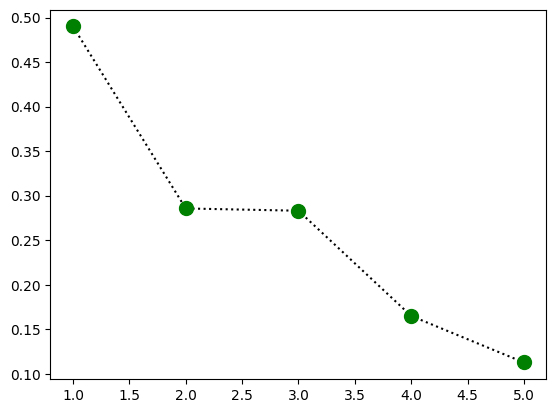

The accuracy for dynamic weighted active domain adaptation using hybrid approach is :  89.38714499252616

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.900, Diversity: 0.100


<ipython-input-8-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 99 samples. Total labeled: 99/1000
Fine-tuning Epoch 1/3, Loss: 0.7276121377944946
Fine-tuning Epoch 2/3, Loss: 0.3285575786139816
Fine-tuning Epoch 3/3, Loss: 0.2941375975497067
Iteration 2: Sampling with weights - Uncertainty: 0.755, Diversity: 0.245
Iteration 2: Selected 98 samples. Total labeled: 197/1000
Fine-tuning Epoch 1/3, Loss: 0.2527148984372616
Fine-tuning Epoch 2/3, Loss: 0.2393636368215084
Fine-tuning Epoch 3/3, Loss: 0.39682488329708576
Iteration 3: Sampling with weights - Uncertainty: 0.636, Diversity: 0.364
Iteration 3: Selected 99 samples. Total labeled: 296/1000
Fine-tuning Epoch 1/3, Loss: 0.27078017592430115
Fine-tuning Epoch 2/3, Loss: 0.23453582264482975
Fine-tuning Epoch 3/3, Loss: 0.19359529111534357
Iteration 4: Sampling with weights - Uncertainty: 0.539, Diversity: 0.461
Iteration 4: Selected 98 samples. Total labeled: 394/1000
Fine-tuning Epoch 1/3, Loss: 0.18195247623953037
Fine-tuning Epoch 2/3, Loss: 0.23681468795984983
Fine-tuning E

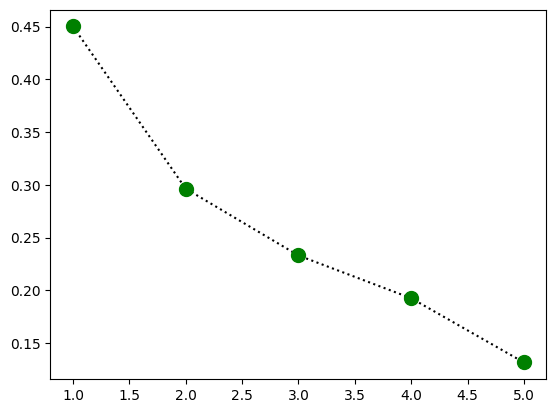

The accuracy for dynamic weighted active domain adaptation using hybrid approach V2 is :  89.93522670652716

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0, Diversity: 1


<ipython-input-8-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 100 samples. Total labeled: 100/1000
Fine-tuning Epoch 1/3, Loss: 0.3349780603311956
Fine-tuning Epoch 2/3, Loss: 0.28966829192359
Fine-tuning Epoch 3/3, Loss: 0.2991410344839096
Iteration 2: Sampling with weights - Uncertainty: 0, Diversity: 1
Iteration 2: Selected 81 samples. Total labeled: 181/1000
Fine-tuning Epoch 1/3, Loss: 0.25602733840545017
Fine-tuning Epoch 2/3, Loss: 0.19171464194854101
Fine-tuning Epoch 3/3, Loss: 0.19672586023807526
Iteration 3: Sampling with weights - Uncertainty: 0, Diversity: 1
Iteration 3: Selected 64 samples. Total labeled: 245/1000
Fine-tuning Epoch 1/3, Loss: 0.2405547872185707
Fine-tuning Epoch 2/3, Loss: 0.21168357878923416
Fine-tuning Epoch 3/3, Loss: 0.1899755820631981
Iteration 4: Sampling with weights - Uncertainty: 1, Diversity: 0
Iteration 4: Selected 96 samples. Total labeled: 341/1000
Fine-tuning Epoch 1/3, Loss: 0.3705836534500122
Fine-tuning Epoch 2/3, Loss: 0.3335769971211751
Fine-tuning Epoch 3/3, Loss: 0.29462473

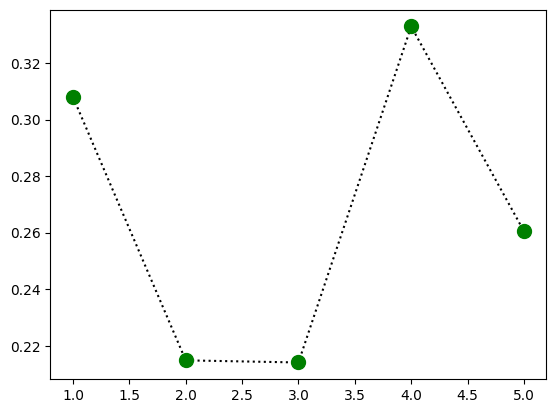

The accuracy for static weighted active domain adaptation using hybrid approach is :  88.58993522670653

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty


<ipython-input-8-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 100 samples. Total labeled: 100/1000
Fine-tuning Epoch 1/3, Loss: 0.4629002958536148
Fine-tuning Epoch 2/3, Loss: 0.3970130383968353
Fine-tuning Epoch 3/3, Loss: 0.31224071606993675
Iteration 2: Sampling with weights - Uncertainty
Iteration 2: Selected 98 samples. Total labeled: 198/1000
Fine-tuning Epoch 1/3, Loss: 0.3250162969343364
Fine-tuning Epoch 2/3, Loss: 0.29241789411753416
Fine-tuning Epoch 3/3, Loss: 0.33153484016656876
Iteration 3: Sampling with weights - Uncertainty
Iteration 3: Selected 98 samples. Total labeled: 296/1000
Fine-tuning Epoch 1/3, Loss: 0.39624186092987657
Fine-tuning Epoch 2/3, Loss: 0.357716859318316
Fine-tuning Epoch 3/3, Loss: 0.3343182671815157
Iteration 4: Sampling with weights - Uncertainty
Iteration 4: Selected 96 samples. Total labeled: 392/1000
Fine-tuning Epoch 1/3, Loss: 0.3339752157529195
Fine-tuning Epoch 2/3, Loss: 0.2963255966703097
Fine-tuning Epoch 3/3, Loss: 0.27466805279254913
Iteration 5: Sampling with weights - Unc

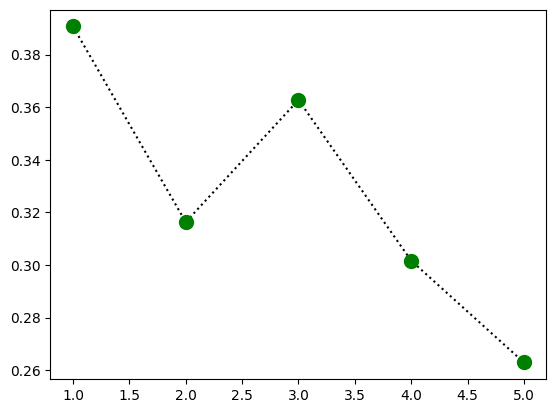

The accuracy for uncertainity active domain adaptation is :  89.53662182361734

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Diversity
Iteration 1: Selected 100 samples. Total labeled: 100/1000
Fine-tuning Epoch 1/3, Loss: 0.30213671328965575
Fine-tuning Epoch 2/3, Loss: 0.3334023058414459
Fine-tuning Epoch 3/3, Loss: 0.27087823674082756
Iteration 2: Sampling with weights - Diversity
Iteration 2: Selected 78 samples. Total labeled: 178/1000
Fine-tuning Epoch 1/3, Loss: 0.15724570800860724
Fine-tuning Epoch 2/3, Loss: 0.12898512557148933
Fine-tuning Epoch 3/3, Loss: 0.16473029553890228
Iteration 3: Sampling with weights - Diversity
Iteration 3: Selected 69 samples. Total labeled: 247/1000
Fine-tuning Epoch 1/3, Loss: 0.10988139609495799
Fine-tuning Epoch 2/3, Loss: 0.09366460889577866
Fine-tuning Epoch 3/3, Loss: 0.08481791242957115
Iteration 4: Sampling with weights - Diversity
Iteration 4: Selected 53 samples. Total labeled: 300/1

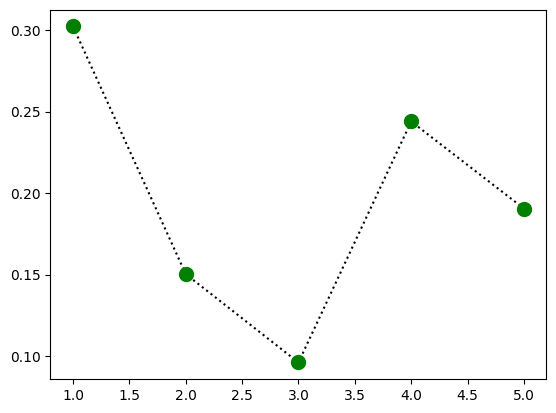

The accuracy for diversity active domain adaptation is :  87.59342301943198



In [15]:

x_model_name=[]
y_model_acc=[]



model=resetting_base_model()
simple_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for Simple Model is : ",simple_acc)
print()

x_model_name.append('Simple Model')
y_model_acc.append(simple_acc)


model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting(model, usps_loader, usps, budget=1000)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model')
dynamic_weightedv1_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach is : ",dynamic_weightedv1_acc)
print()

x_model_name.append('Dynamic Weighted Active Model')
y_model_acc.append(dynamic_weightedv1_acc)


model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting_v2(model, usps_loader, usps, budget=1000)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model_v2')
dynamic_weightedv2_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach V2 is : ",dynamic_weightedv2_acc)
print()

x_model_name.append('Dynamic Weighted Active Model V2')
y_model_acc.append(dynamic_weightedv2_acc)



model=resetting_base_model()
active_domain_adaptation_with_fixed_weighting(model, usps_loader, usps, budget=1000)
torch.save(model.state_dict(), '/content/models/static_active_cnn_model')
static_weighted_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for static weighted active domain adaptation using hybrid approach is : ",static_weighted_acc)
print()

x_model_name.append('Static Weighted Active Model')
y_model_acc.append(static_weighted_acc)



model=resetting_base_model()
active_domain_adaptation_with_uncertainity_sampling(model, usps_loader, usps, budget=1000)
torch.save(model.state_dict(), '/content/models/uncertainity_active_cnn_model')
uncertainity_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for uncertainity active domain adaptation is : ",uncertainity_acc)
print()

x_model_name.append('Uncertainity Active Model')
y_model_acc.append(uncertainity_acc)

model=resetting_base_model()
active_domain_adaptation_with_diversity_sampling(model, usps_loader, usps, budget=1000)
torch.save(model.state_dict(), '/content/models/diversity_active_cnn_model')
diversity_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for diversity active domain adaptation is : ",diversity_acc)
print()

x_model_name.append('Diversity Active Model')
y_model_acc.append(diversity_acc)




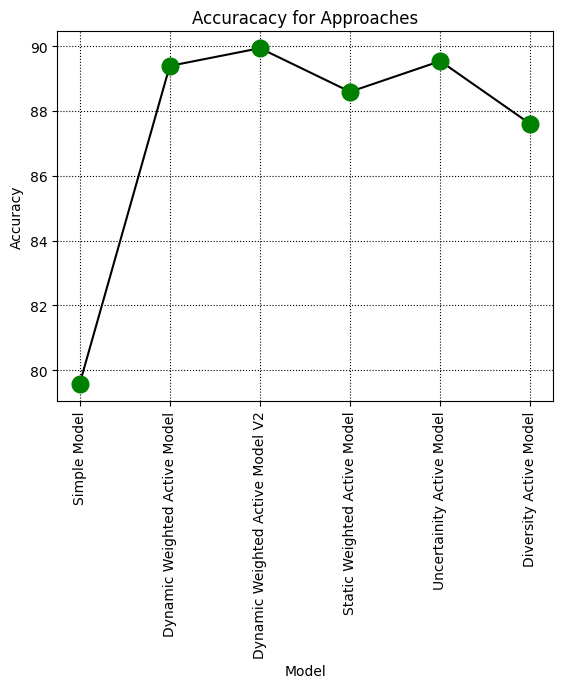

In [19]:
plt.plot(x_model_name,y_model_acc,marker='o',linestyle='-',mfc='green',mec='green',color='black',ms=12)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracacy for Approaches')
plt.grid(axis='x',linestyle=':',color='black')
plt.grid(axis='y',linestyle=':',color='black')
plt.xticks(rotation=90)
plt.show()
